# Supplementary Figure S25: `s25_high_control_examples_leap`

This notebook rebuilds the figure step by step from its script, `figures/supplementary/sup_high_control_examples.py`. Every code cell below is a verbatim slice of that file, in the order the file defines it: first the imports and configuration, then each helper function with a short explanation, then the body of `main()` laid out as the assembly of the panels, and finally the rendered figure with its caption. Run the cells top to bottom; in the reference environment the PNG written at the end is identical to the submitted manuscript file (see docs/REPRODUCIBILITY.md).

Figures S22 to S26 are a gallery of the best-controlled site-model pairs, one figure per macaque. For each monkey the script picks the four site-model combinations with the highest control correlation and shows, side by side, what the accentuation sweep looked like and how well the model's predicted responses matched the measured control-phase responses. The image strips come from the raw control stimuli on disk; the scatter draws on the cached per-stimulus predictions and the control-session responses. The point is to make the abstract control score concrete: these are the cases where a parametric sweep through a model's feature axis produced a matching parametric sweep in the neuron.

## What the script says about itself

Supp. Fig. (slug high_control_examples) - top high-control example sweeps.

For the highest control-r site-model combinations, show the accentuation sweep alongside the predicted-vs-measured control scatter (per-seed connectors, dots colored by feature level, model-colored linear fit) with the pair's r and slope. Each example shows the TWO highest-R2 seed sweeps as a 2x6 image grid (one seed per row, suppress -> drive) beside the scatter. Per-monkey galleries span the manifest number block (base num FROM MANIFEST, never hardcoded). Self-contained : data via pnc.preproc.loader; raw stimulus images from STIMULI_CONTROL_PATH.

python -m figures.supplementary.sup_high_control_examples --out DIR [--monkey red]

## 1. Environment

A few lines that are not in the script: they make the notebook render exactly like the command-line harness does (single-threaded BLAS, the Agg backend with matplotlib defaults, the repository on the import path) and check that the preprocessed data are present.

In [1]:
import os, sys
from pathlib import Path

# Keep BLAS single-threaded: multithreaded OpenMP together with torch can kill the kernel on macOS.
for _v in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ.setdefault(_v, '1')
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

# Render with the Agg backend and matplotlib's defaults, exactly like the figure scripts;
# Jupyter's inline backend would otherwise change dpi and bounding boxes.
os.environ['MPLBACKEND'] = 'Agg'
import matplotlib; matplotlib.use('Agg'); matplotlib.rcdefaults()

# Work from the repository root whether the notebook is opened there or in notebooks/figures/.
REPO = Path.cwd() if (Path.cwd() / 'pnc').exists() else Path.cwd().parents[1]
sys.path.insert(0, str(REPO))
from pnc import paths

# The figures read the preprocessed caches only; this raises a clear message if they are missing.
paths.require(paths.preprocessed_data() / 'brain_red.pkl')   # python data/download_data.py --tier preprocessed
OUT_DIR = paths.output_dir() / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Imports, style and configuration

The script starts by importing the study configuration and figure style from `pnc` (colours, model names, the publication rcParams) and the cache loader, then fixes the constants that the panels share: which sites and models are shown, layout sizes, colour choices, and where the inputs live. `apply_figure_style()` is what makes every figure in the paper look the same.

`MONKEYS` lists the five animals and `MONKEY_NUM` pairs each with its supplementary figure number, taken from the manifest rather than hardcoded. `N_EX` sets how many examples (rows) each figure shows, `N_STRIP` how many images are sampled from each sweep for the strip, and `N_ROW` how many seed sweeps are shown per example. `CMAP` is the diverging red-blue map used for both the image borders and the scatter dots, so blue always means suppress and red always means drive.

In [2]:
import os

import glob

from collections import defaultdict

from pnc import paths

from pnc.manifest import fig as _fig, output_name

from pnc.preproc import loader as L

from pnc.utils import (apply_figure_style, FONT_FAMILY, MM, WIDTH_2COL_MM, FIG_FACECOLOR, save_fig,
                       MODEL_COLORS, MODEL_SHORT_NAMES, ROBUST_MODELS, MONKEY_COLORS, get_model_color,
                       STIMULI_CONTROL_PATH)

apply_figure_style(); _M = _fig('high_control_examples')



import numpy as np

import matplotlib

matplotlib.use('Agg')

import matplotlib.pyplot as plt

import matplotlib.colors as mcolors

from matplotlib.gridspec import GridSpec

from PIL import Image

from scipy import stats

MODEL_SHORT_NAMES['AlexNet_training_seed_01'] = 'Untrained'

CTRL = STIMULI_CONTROL_PATH

MONKEY_TAG = {'red': 'R', 'paul': 'P', 'venus': 'V', 'leap': 'L', 'three0': 'T'}

MONKEY_REGION = {'red': 'aIT', 'paul': 'cIT', 'venus': 'V3/V4', 'leap': 'STS', 'three0': 'STS'}

# One figure per monkey, each showing that monkey's top-N site-model combos by control r.
# S-numbers come from the manifest span (base = fig num); monkey index sets the offset.
_BASE_NUM = _M['num']

MONKEYS = ['red', 'paul', 'venus', 'leap', 'three0']

MONKEY_NUM = [(mk, _BASE_NUM + i) for i, mk in enumerate(MONKEYS)]

N_EX = 4                                     # top examples (rows) per monkey

N_STRIP = 6                                  # sweep images per seed row (suppress -> drive)

N_ROW = 2                                    # seed rows per example (2 highest-R2 seeds)

## 3. The building blocks

Each function below is one component of the figure: loading and shaping a cache, computing a statistic, or drawing one panel into an axes it is handed. They are defined here exactly as in the script and used by the assembly in the last section; read them in order, the assembly calls them in roughly the same order.

The helpers split into two groups: those that select and shape the data (`top_examples`, `cloud_named`, `_seed_r2`, `top_seed_sweeps`) and those that find the stimulus images on disk (`image_dir`, `resolve_image`). `render` then does all of the drawing for one monkey.

### `top_examples(mk, n=N_EX)`

Reads the study-wide control table, keeps the rows for one monkey that have a defined control correlation, and returns the top `n` (monkey, unit, model) triples sorted by control `r`. This is the only place where the choice of examples is made.

In [3]:
def top_examples(mk, n=N_EX):
    ct = L.control_table()
    sub = ct[(ct.monkey == mk) & ct.control_r.notna()].sort_values('control_r', ascending=False)
    return [(mk, int(r.unit), r.model) for r in sub.head(n).itertuples()]

More configuration used by the functions below.

In [4]:
CMAP = plt.colormaps['RdBu_r']

FS_TITLE, FS_AX, FS_TICK, FS_ANN = 7, 6.5, 6, 6

### `cloud_named(mk, u, m)`

(name, floored pred, measured z, seed, level) over the personalized accentuated sweep.

Rebuilds the predicted-versus-measured cloud for one site-model, but keeps the stimulus name, seed and feature level alongside each point so the sweep can be reconstructed later. Predictions are floored at the site's firing floor, matching the convention used for the control score elsewhere in the paper, and stimuli with no recorded response are dropped.

In [5]:
def cloud_named(mk, u, m):
    """(name, floored pred, measured z, seed, level) over the personalized accentuated sweep."""
    P = L.load_predictions(mk)
    mi = list(P['pred_models']).index(m); ui = list(P['target_units']).index(u)
    sel = (P['gen_model'] == m) & (P['gen_unit'] == u)
    resp = L._acc_response(mk, u); fl = L.firing_floor(mk, u)
    out = []
    for n, p, s, lv in zip(P['stim'][sel], P['pred'][sel, mi, ui], P['gen_seed'][sel], P['gen_level'][sel]):
        if n in resp:
            out.append((str(n), max(float(p), fl), float(resp[n]), int(s), float(lv)))
    return out

### `image_dir(mk, m)`

Locates the accentuation image folder for a given monkey and model under the control stimulus root by name pattern.

In [6]:
def image_dir(mk, m):
    cands = [d for d in sorted(os.listdir(CTRL)) if mk in d and d.endswith(f'_{m}_accentuation')]
    return os.path.join(CTRL, cands[0]) if cands else None

### `resolve_image(mk, m, name)`

Resolve a control stimulus name to its file on the drive (basename match).

Turns a control stimulus name into a file path inside that folder, falling back to a glob if the exact name is not present. Returns nothing if the image is missing, which `render` records rather than failing.

In [7]:
def resolve_image(mk, m, name):
    """Resolve a control stimulus name to its file on the drive (basename match)."""
    d = image_dir(mk, m)
    if d is None:
        return None
    p = os.path.join(d, name)
    if os.path.exists(p):
        return p
    hits = sorted(glob.glob(os.path.join(d, name)))
    return hits[0] if hits else None

### `_seed_r2(lst)`

Floored-prediction R2 for one seed sweep: 1 - SS_res / SS_tot (loader convention).

Computes an R-squared for a single seed sweep, comparing floored predictions to measured responses with the loader's one-minus-residual-over-total convention. It is used only to rank seeds, not for any reported statistic.

In [8]:
def _seed_r2(lst):
    """Floored-prediction R2 for one seed sweep: 1 - SS_res / SS_tot (loader convention)."""
    p = np.array([q[1] for q in lst]); me = np.array([q[2] for q in lst])
    ss = np.sum((me - me.mean()) ** 2)
    return 1.0 - np.sum((me - p) ** 2) / ss if ss > 0 else -np.inf

### `top_seed_sweeps(rows, n=N_ROW)`

The n seeds with the highest per-seed R2; each as a level-sorted [(lv, name), ...].

Groups the cloud by seed, ranks the seeds by `_seed_r2`, and returns the best `n` as level-sorted lists of (level, stimulus name). These become the image rows.

In [9]:
def top_seed_sweeps(rows, n=N_ROW):
    """The n seeds with the highest per-seed R2; each as a level-sorted [(lv, name), ...]."""
    byseed = defaultdict(list)
    for name, p, me, s, lv in rows:
        byseed[s].append((lv, p, me, name))
    ranked = sorted(byseed.items(), key=lambda kv: _seed_r2(kv[1]), reverse=True)
    return [[(q[0], q[3]) for q in sorted(lst)] for _, lst in ranked[:n]]

### `render(out_dir, num, PICKS)`

Draws one monkey's figure. Each example gets a row split into a two-by-six image grid on the left and a square scatter on the right. The grid shows six evenly spaced levels from each of the two best seed sweeps, with a border colored by feature level. The scatter plots every accentuated stimulus for that site-model, links the levels of each seed with a thin dotted line, colors dots by predicted response, and overlays a least-squares fit in the model's color with the pair's Pearson `r` and slope annotated. A shared colorbar and a title identifying the monkey and area sit at the top, and the function returns the saved path plus the key numbers and any missing images.

In [10]:
def render(out_dir, num, PICKS):
    stem = output_name('high_control_examples', PICKS[0][0])
    fig = plt.figure(figsize=(WIDTH_2COL_MM * MM, min(232, 42 * len(PICKS) + 22) * MM),
                     facecolor=FIG_FACECOLOR)
    outer = GridSpec(len(PICKS), 1, figure=fig, left=0.035, right=0.975,
                     top=0.905, bottom=0.055, hspace=0.42)

    key_numbers = {}
    missing = []
    for ri, (mk, u, m) in enumerate(PICKS):
        rows = cloud_named(mk, u, m)
        pf = np.array([r[1] for r in rows]); mf = np.array([r[2] for r in rows])
        reg = stats.linregress(pf, mf)
        r_pair = float(reg.rvalue); slope = float(reg.slope)
        col = get_model_color(m)
        short = MODEL_SHORT_NAMES[m]
        tag = f'{short} | Monkey {MONKEY_TAG[mk]} {MONKEY_REGION[mk]} ch{u}'
        key_numbers[f'{short}_{mk}_u{u}'] = {'control_r': round(r_pair, 2),
                                             'control_slope': round(slope, 2)}

        # split the row: 2x6 image grid (left) + scatter (right, spans both rows)
        gr = outer[ri].subgridspec(1, 2, width_ratios=[N_STRIP, 2.7], wspace=0.12)

        # ---- accentuation sweeps: 2 highest-R2 seeds, one per row (suppress -> drive) ----
        sweeps = top_seed_sweeps(rows)
        all_lv = [r[4] for r in rows]
        norm_lv = mcolors.Normalize(vmin=min(all_lv), vmax=max(all_lv))
        grid = gr[0].subgridspec(N_ROW, N_STRIP, wspace=0.06, hspace=0.06)
        for rj in range(N_ROW):
            seq = sweeps[rj] if rj < len(sweeps) else []
            picks = []
            if seq:
                idx = np.linspace(0, len(seq) - 1, N_STRIP).round().astype(int)
                picks = [seq[i] for i in idx]
            for ci in range(N_STRIP):
                axi = fig.add_subplot(grid[rj, ci])
                axi.set_xticks([]); axi.set_yticks([])
                if ci < len(picks):
                    lv, name = picks[ci]
                    fp = resolve_image(mk, m, name)
                    if fp is None:
                        missing.append(f'{mk}/{m}/{name}')
                        axi.set_facecolor('#eee')
                    else:
                        axi.imshow(np.asarray(Image.open(fp).convert('RGB')))
                    for s in axi.spines.values():
                        s.set_visible(True); s.set_linewidth(1.6); s.set_edgecolor(CMAP(norm_lv(lv)))
                else:
                    axi.set_facecolor('white')
                    for s in axi.spines.values():
                        s.set_visible(False)
                if ri == 0 and rj == 0 and ci == 0:
                    axi.set_title('suppress', fontsize=FS_TICK, fontfamily=FONT_FAMILY,
                                  color='#3B4CC0', pad=2, loc='left')
                if ri == 0 and rj == 0 and ci == N_STRIP - 1:
                    axi.set_title('drive', fontsize=FS_TICK, fontfamily=FONT_FAMILY,
                                  color='#B40426', pad=2, loc='right')

        # ---- predicted vs measured scatter ----
        ax = fig.add_subplot(gr[1])
        lo = float(min(pf.min(), mf.min())); hi = float(max(pf.max(), mf.max()))
        mg = (hi - lo) * 0.08; lims = (lo - mg, hi + mg)
        norm = mcolors.Normalize(vmin=pf.min(), vmax=pf.max())
        ax.plot(lims, lims, 'k--', lw=0.6, alpha=0.35, zorder=1)
        byseed = defaultdict(list)
        for n, p, me, s, lv in rows:
            byseed[s].append((lv, p, me))
        for s, lst in byseed.items():
            lst.sort()
            ps = np.array([q[1] for q in lst]); ms = np.array([q[2] for q in lst])
            ax.plot(ps, ms, ls=':', color='#777', lw=0.5, alpha=0.6, zorder=3)
        ax.scatter(pf, mf, s=9, c=[CMAP(norm(x)) for x in pf],
                   edgecolors='black', linewidths=0.2, zorder=5)
        xf = np.linspace(pf.min(), pf.max(), 50)
        ax.plot(xf, reg.slope * xf + reg.intercept, color=col, lw=2.0, zorder=6)
        # data trend runs lower-left -> upper-right, so the upper-left corner is empty
        ax.text(0.04, 0.96, f'$r$ = {r_pair:.2f}\nslope = {slope:.2f}',
                transform=ax.transAxes, ha='left', va='top', fontsize=FS_ANN,
                fontfamily=FONT_FAMILY, zorder=14,
                bbox=dict(boxstyle='round,pad=0.28', fc='white', ec='#cccccc', lw=0.5, alpha=0.9))
        ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect('equal')
        ax.tick_params(labelsize=FS_TICK, length=2.5, width=0.6)
        ax.set_xlabel('Predicted response (z)', fontsize=FS_AX, fontfamily=FONT_FAMILY)
        ax.set_ylabel('Measured neural (z)', fontsize=FS_AX, fontfamily=FONT_FAMILY)

        # row title spanning the block
        y0 = outer[ri].get_position(fig).y1
        fig.text(0.035, y0 + 0.010, f'{chr(97 + ri)}', fontsize=10, fontweight='bold',
                 ha='left', va='bottom', fontfamily=FONT_FAMILY)
        fig.text(0.072, y0 + 0.012, tag, fontsize=FS_TITLE, fontweight='bold',
                 ha='left', va='bottom', color=col, fontfamily=FONT_FAMILY)

    # feature-level colorbar (top-right)
    sm = plt.cm.ScalarMappable(norm=mcolors.Normalize(0, 1), cmap=CMAP); sm.set_array([])
    cax = fig.add_axes([0.70, 0.955, 0.26, 0.011])
    cb = fig.colorbar(sm, cax=cax, orientation='horizontal', ticks=[])
    cb.set_label('feature level: suppress to drive', fontsize=FS_TICK, fontfamily=FONT_FAMILY)
    cb.ax.xaxis.set_label_position('top'); cb.outline.set_linewidth(0.5)

    mk0 = PICKS[0][0]
    fig.text(0.035, 0.965, f"{_M['title']} - Monkey "
             f"{MONKEY_TAG[mk0]} ({MONKEY_REGION[mk0]})",
             fontsize=9, fontweight='bold', ha='left', va='center', fontfamily=FONT_FAMILY)

    out = save_fig(fig, os.path.join(out_dir, stem))
    plt.close(fig)
    print(f'{mk0:8s} S{num}  saved -> {out}')
    print('  key_numbers:', key_numbers)
    if missing:
        print('  MISSING IMAGES:', missing)
    return out, key_numbers, missing

## 4. Assembling the figure

This is the body of `main()` from the script, laid out step by step: it builds the figure canvas, calls the building blocks to fill each panel, and saves the result with `save_fig`, which trims the white border so the file matches the submitted figure.

Render one per-monkey gallery (monkey='red'...) or, with monkey=None, all five. Returns the PNG path (one monkey) or the list of PNG paths (all).

`main` is short: it loops over the five monkeys, calls `top_examples` to choose that monkey's four best site-models, and hands them to `render`. In the notebook the `monkey` parameter is set to one animal, so only that figure is built.

In [11]:
# Inputs of the assembly below (these are the parameters of main() in the script).
out_dir = str(OUT_DIR)
monkey = 'leap'
# Change any of them to render one of the variants described in the script header.

**Step 1**

Iterates over `MONKEY_NUM`, skips animals that do not match `monkey`, and renders one gallery per selected animal. With `monkey` set, `png` is the single output path; with `monkey` left as `None` it would be the list of all five.

In [12]:
outs = []
for mk, num in MONKEY_NUM:
    if monkey is not None and mk != monkey:
        continue
    outs.append(render(out_dir, num, top_examples(mk))[0])
png = outs[0] if monkey is not None else outs

leap     S25  saved -> /private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/s25_high_control_examples_leap.png
  key_numbers: {'CLIPAG_leap_u282': {'control_r': 0.82, 'control_slope': 1.06}, 'RegNetY_leap_u282': {'control_r': 0.78, 'control_slope': 1.02}, 'RADIO_leap_u282': {'control_r': 0.78, 'control_slope': 0.77}, 'CLIPAG_leap_u286': {'control_r': 0.77, 'control_slope': 0.7}}


## 5. The figure

`png` now points at the rendered file. A downscaled preview follows (the full-resolution PNG is the file itself, `s25_high_control_examples_leap.png` in the output directory).

Look at how the image strips change smoothly from the blue (suppress) end to the red (drive) end, and how the dots in the scatter follow the fit line with the seed connectors running roughly parallel to it. Set `monkey` to `'red'`, `'paul'`, `'venus'`, `'leap'` or `'three0'` to render S22 through S26 respectively.

/private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/s25_high_control_examples_leap.png


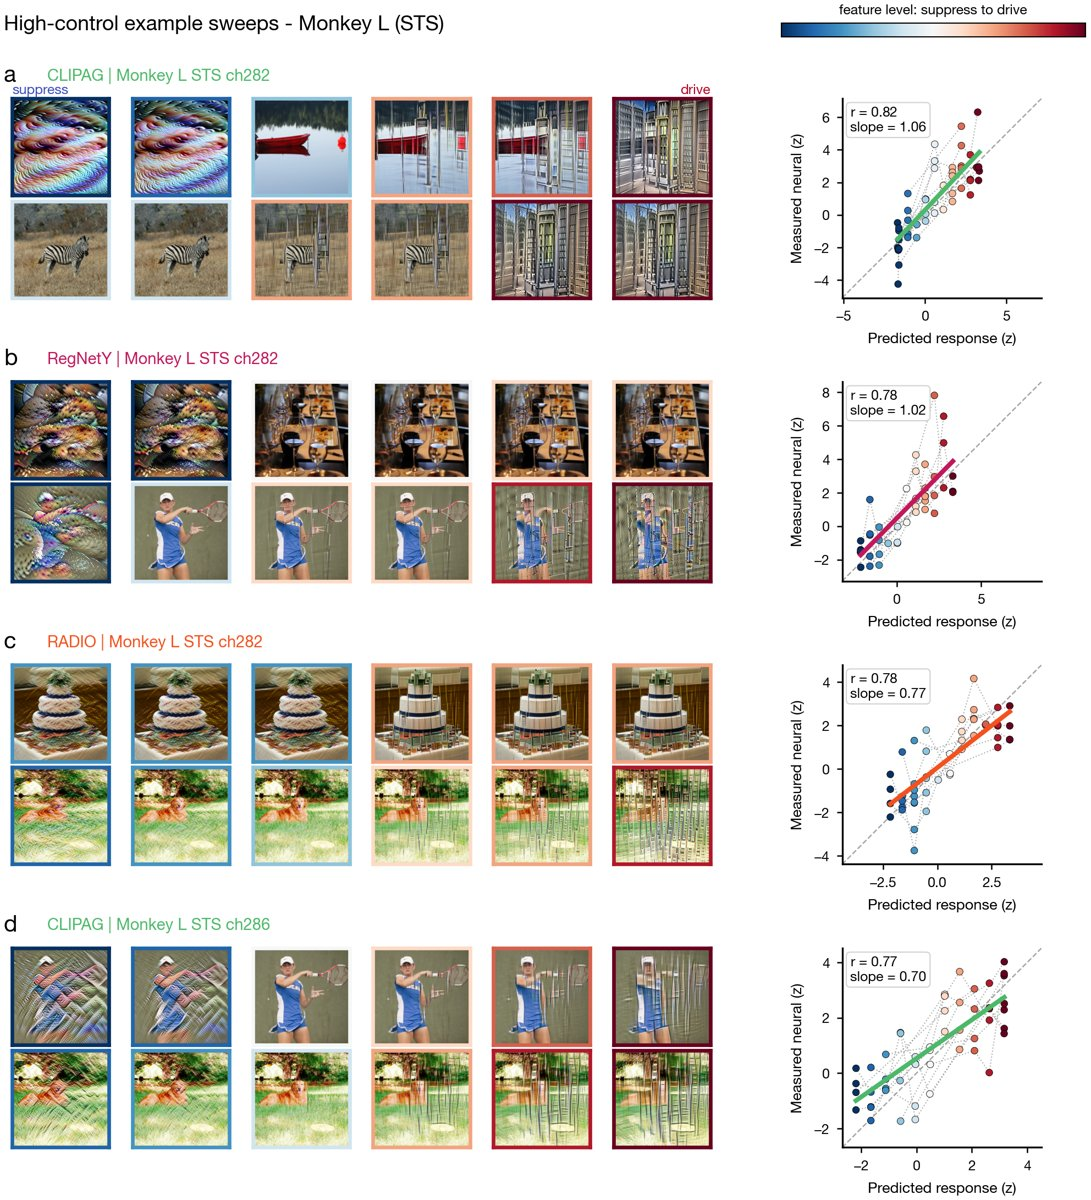

In [13]:
import io
from IPython.display import Image, display
from PIL import Image as PILImage

# A JPEG preview keeps the notebook small; open the PNG for full detail.
print(png)
im = PILImage.open(png).convert("RGB")
im.thumbnail((1200, 1200))
buf = io.BytesIO(); im.save(buf, "JPEG", quality=85, optimize=True)
display(Image(data=buf.getvalue(), format="jpeg", width=900))

**Supplementary Figure S25. High-control example sweeps (leap).** Each figure shows, for one macaque, the four site-model combinations with the highest parametric-control correlation. For each instance, we plot the two highest-$R^2$ seed sweeps (one seed per row, suppress levels to drive levels according to the color of the image borders) beside the predicted-versus-measured control scatter, in which thin lines link the eleven levels of each seed sweep. Dots are colored by feature level, and a solid line gives the least-squares fit with the pair's Pearson $r$ and slope outcome measures annotated. These examples illustrate strong predicted-to-measured correspondence across full accentuation sweeps.